In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

# Optional: Preview the first few rows
df.head()


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,CIR_PWR,MAX_NOISE,RXPACC
0,0,3.90,745,18712,10250,11576,11855,967,611
1,0,0.66,749,11239,6313,4712,18968,1133,447
2,1,7.86,746,4355,5240,3478,14699,894,723
3,1,3.48,750,8502,8416,5890,8748,1127,1024
4,0,1.19,746,17845,18095,12058,11380,1744,276


In [2]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

Logistic Regression Test Accuracy: 0.8581746031746031

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      6278
           1       0.90      0.81      0.85      6322

    accuracy                           0.86     12600
   macro avg       0.86      0.86      0.86     12600
weighted avg       0.86      0.86      0.86     12600

Confusion Matrix:
[[5712  566]
 [1221 5101]]


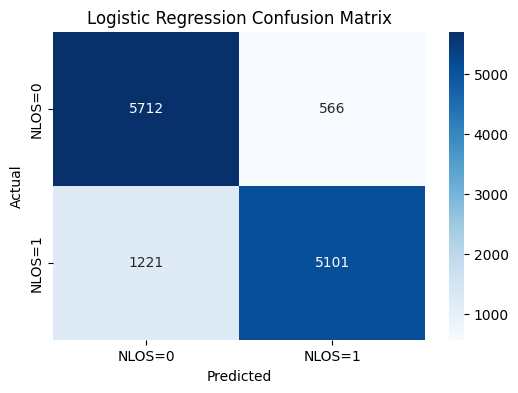

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create and train the Logistic Regression model
logreg = LogisticRegression(random_state=111, max_iter=500)
logreg.fit(X_train, y_train)

# 2. Predict on the test set
y_pred_logreg = logreg.predict(X_test)

# 3. Evaluate the performance
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print("Logistic Regression Test Accuracy:", accuracy_logreg)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

# 4. Compute and display the confusion matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
print("Confusion Matrix:")
print(cm_logreg)

plt.figure(figsize=(6,4))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()
